The objective of this notebook is to create an end-to-end flood prediction pipeline using the trained pretrained-backbone (MobileNetV2) + transformer model. A new SAR image is loaded, preprocessed, and passed directly to the model to predict whether the image contains flooded regions. This notebook serves as the foundation for the web dashboard, where uploaded images will be automatically analyzed and classified as flood-prone or non-flood-prone.

**Note:** this version no longer uses an autoencoder or a separate classifier (Random Forest) — `simple_transformer_pretrained_final.keras` is a single, self-contained model. MobileNetV2 and the transformer head are baked into one saved file, so inference is a single `model.predict()` call.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import load_model


In [3]:
MODEL_DIR = "/content/drive/MyDrive/sar-project/models"
TEST_IMAGE_DIR = "/content/drive/MyDrive/sar-project/test_images"


In [4]:
print(os.listdir(MODEL_DIR))


['random_forest_flood_classifier.pkl', 'autoencoder.h5', 'autoencoder.keras', 'encoder.keras', 'vision_transformer.keras', 'vision_transformer_final.keras', 'vit_training_history.npy', 'vit_results.npy', 'cnn_transformer.keras', 'simple_transformer.keras', 'simple_transformer_phase1.keras', 'simple_transformer_phase2.keras', 'simple_transformer_history.npy', 'simple_transformer_final.keras', 'autoencoder_dualpol.keras', 'encoder_dualpol.keras', 'dualpol_fold1_phase1.keras', 'dualpol_fold1_phase2.keras', 'dualpol_fold2_phase1.keras', 'dualpol_fold2_phase2.keras', 'dualpol_fold3_phase1.keras', 'dualpol_fold3_phase2.keras', 'dualpol_fold4_phase1.keras', 'dualpol_fold4_phase2.keras', 'dualpol_fold5_phase1.keras', 'dualpol_fold5_phase2.keras', 'dualpol_final_deployment_phase1.keras', 'simple_transformer_dualpol_final.keras', 'dualpol_frozen_fold1_phase1.keras', 'dualpol_frozen_fold2_phase1.keras', 'dualpol_frozen_fold3_phase1.keras', 'dualpol_frozen_fold4_phase1.keras', 'dualpol_frozen_fold

In [5]:
#PositionEmbedding - the custom layer class used inside the saved model.
#Keras needs this exact class available in this notebook's session to reconstruct
#the model - it cannot infer custom layer code from the saved file alone.
#
#IMPORTANT: __init__ must accept **kwargs and forward them to super().__init__()  -
#Keras also passes standard layer args (trainable, dtype, name, ...) when rebuilding
#this layer from the saved config, and without **kwargs there is nowhere for them to
#go. get_config() is also defined explicitly so save/load stays reliable going forward.
class PositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )

    def call(self, inputs):
        positions = tf.range(start=0,
                             limit=tf.shape(inputs)[1],
                             delta=1)
        embedded_positions = self.position_embedding(positions)
        return inputs + embedded_positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "embed_dim": self.embed_dim,
        })
        return config


In [6]:
#LOAD THE MODEL - single self-contained file, no autoencoder or separate classifier needed
#custom_objects: required so Keras can resolve the PositionEmbedding layer above
#safe_mode=False: required because the model also contains a raw Python Lambda layer
#(the channel-tiling/rescaling step before MobileNetV2) - Keras blocks deserializing
#arbitrary lambdas by default for security, so this has to be explicitly allowed
model = load_model(
    os.path.join(
        MODEL_DIR,
        "simple_transformer_pretrained_final.keras"
    ),
    custom_objects={"PositionEmbedding": PositionEmbedding},
    safe_mode=False
)
print("Model Loaded")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'position_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model Loaded


In [7]:
#DECISION THRESHOLD - tuned during training/validation, NOT the default 0.5.
#The dataset is heavily imbalanced (~87% No-Flood), so the model was tuned to flag
#flood at a lower probability cutoff than 0.5 - using 0.5 here would under-detect floods.
DECISION_THRESHOLD = 0.20


In [8]:
test_image_path = (
    "/content/drive/MyDrive/sar-project/sar_test_images/testimg.jpeg"
)


In [9]:
#READ SAR IMAGE
if not os.path.exists(test_image_path):
    print(f"Error: Image file not found at {test_image_path}")
    img = None
else:
    img = cv2.imread(
        test_image_path,
        cv2.IMREAD_GRAYSCALE
    )

if img is not None:
    print(img.shape)
else:
    print("Error: Could not load image. Check the file path and image integrity.")


(232, 217)


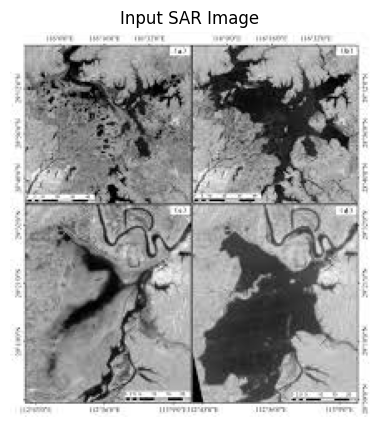

In [10]:
#DISPLAY ORIGINAL IMAGE
plt.figure(figsize=(5,5))
plt.imshow(
    img,
    cmap="gray"
)
plt.title("Input SAR Image")
plt.axis("off")
plt.show()


In [11]:
#RESIZING IMAGE
img = cv2.resize(
    img,
    (128,128)
)
print(img.shape)


(128, 128)


In [12]:
#NORMALIZE
img = img.astype(np.float32)
img = img / 255.0


In [13]:
#ADD CHANNEL DIMENSION
#model input is (128,128,1) - it tiles this into 3 fake-RGB channels internally,
#so no channel-related preprocessing is needed here beyond this
img = np.expand_dims(
    img,
    axis=-1
)


In [14]:
#ADD BATCH DIMENSION
img = np.expand_dims(
    img,
    axis=0
)
print(img.shape)


(1, 128, 128, 1)


In [15]:
#PREDICT FLOOD PROBABILITY - single model call, no separate feature extraction step
flood_probability = model.predict(img)[0][0]
print(f"Raw model output (probability of Flood): {flood_probability:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Raw model output (probability of Flood): 0.0117


In [16]:
#APPLY TUNED DECISION THRESHOLD
prediction = 1 if flood_probability >= DECISION_THRESHOLD else 0

if prediction == 1:
    print("⚠️ Flood-Prone Area Detected")
else:
    print("✅ No Flood Detected")


✅ No Flood Detected


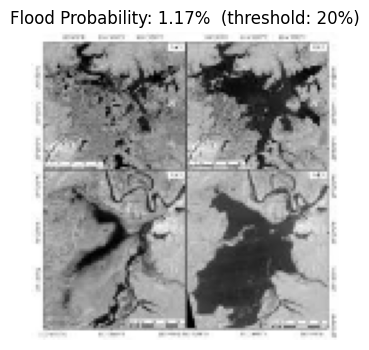

In [17]:
#VISUAL RESULT
flood_prob_pct = flood_probability * 100
plt.figure(figsize=(6,4))
plt.imshow(
    img[0].squeeze(),
    cmap="gray"
)
plt.title(f"Flood Probability: {flood_prob_pct:.2f}%  (threshold: {DECISION_THRESHOLD*100:.0f}%)")
plt.axis("off")
plt.show()


In [18]:
#SAVE PREDICTION REPORT
result = {
    "Prediction": "Flood" if prediction == 1 else "No Flood",
    "Flood Probability": float(flood_prob_pct),
    "Decision Threshold": DECISION_THRESHOLD
}
print(result)


{'Prediction': 'No Flood', 'Flood Probability': 1.1715128421783447, 'Decision Threshold': 0.2}
